# Thermal Profile

Analysis of core battery temperature change over time with and without external styrofoam insulation.

In [5]:
import os
import matplotlib
from matplotlib import pyplot as plt
import pandas as pd

import darkdetect

plt.rcdefaults()

if darkdetect.isDark():
    plt.style.use("dark_background")

plt.rcParams.update(
    {
        "figure.dpi": 300,
        "figure.figsize": (8, 6),
    }
)

%config InlineBackend.figure_formats = ["svg"]
# %config InlineBackend.figure_format = 'retina'

In [6]:
THERMAL_DATA_CSV = "../Data/Calorimetry/HR12-9 Calorimetry.csv"

therm_df = pd.read_csv(THERMAL_DATA_CSV, sep="	")
# Format Date/Time as duration
therm_df["Date/Time"] = pd.to_datetime(therm_df["Time"], format="%H:%M:%S")

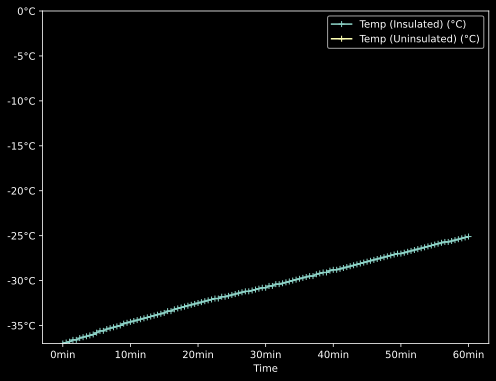

In [7]:
from matplotlib.ticker import FuncFormatter

ax = therm_df.plot(
    x="Time",
    y=["Temp (Insulated) (°C)", "Temp (Uninsulated) (°C)"],
    ylim=(therm_df["Temp (Insulated) (°C)"].min(), 0),
    marker="+",
)
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{int(x)}°C"))
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{int(x/2)}min"))